In [1]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import LinearRegression
import os

In [2]:
NUM_COLS = ["atemp","hum"]
CAT_COLS = ["mnth","hr",'weekday',"workingday","weathersit","is_rush_hour","is_overtime_hour","is_weekend_leisure"]

In [3]:
def build_preprocessors(available_cols):
    """
    Tiền xử lý tối giản: Số/Binary dùng StandardScaler, Categorical dùng OneHotEncoder.
    Loại bỏ hoàn toàn Polynomial và Cyclical transformations phức tạp.
    """
    num_cols = [c for c in available_cols if c in NUM_COLS]
    cat_cols = [c for c in available_cols if c in CAT_COLS]

    # ==========================================
    # 1. PREPROCESSOR CHO LINEAR MODELS
    # ==========================================
    transformers_line = []

    if num_cols:
        # Bọc PolynomialFeatures và StandardScaler thành một pipeline con
        num_pipeline = Pipeline([
            ("poly", PolynomialFeatures(include_bias=False)),
            ("scaler", StandardScaler())
        ])
        transformers_line.append(("num", num_pipeline, num_cols))

    if cat_cols:
        transformers_line.append((
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            cat_cols
        ))
    prep_line = ColumnTransformer(transformers=transformers_line)

    # ==========================================
    # 2. PREPROCESSOR CHO TREE MODELS (RF/LightGBM/XGBoost)
    # ==========================================
    tree_passthrough_cols = list(num_cols) + list(cat_cols)


    transformers_tree = []
    if tree_passthrough_cols:
        transformers_tree.append(("passthrough_features", "passthrough", tree_passthrough_cols))

    prep_tree = ColumnTransformer(transformers=transformers_tree)

    return prep_line, prep_tree

In [4]:
def get_param_grids(prep_line, prep_tree):
    """
    Trả về dict cấu hình model + param distributions cho RandomizedSearchCV.
    Bao gồm: Linear Regression (Baseline), Decision Tree, Random Forest, LightGBM và XGBoost.
    """
    pipe_lin = Pipeline([
        ("prep", prep_line),
        ("lin", LinearRegression())
    ])
    pipe_tree = Pipeline([("prep", prep_tree), ("tree", DecisionTreeRegressor(random_state=42))])
    pipe_rf = Pipeline([("prep", prep_tree), ("rf", RandomForestRegressor(random_state=42, n_jobs=-1))])
    pipe_lgb = Pipeline([("prep", prep_tree), ("lgb", lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1,enable_categorical=True))])
    pipe_xgb = Pipeline([("prep", prep_tree), ("xgb", xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0,enable_categorical=True))])

    return {
        "Linear Regression (Baseline)": {
            "model": pipe_lin,
            "params": {
                "prep__num__poly__degree": [1, 2]
            },
            # 2 tổ hợp
        },
        "Decision Tree": {
            "model": pipe_tree,
            "params": {
                "tree__max_depth": [3, 5, 8, 12, 20],
                "tree__min_samples_leaf": [1, 5, 10, 20],
                "tree__max_features": ["sqrt", 0.5, 0.7, 1.0],
            },
            # 5 x 4 x 4 = 80 tổ hợp
        },
        "Random Forest": {
            "model": pipe_rf,
            "params": {
                "rf__n_estimators": [100, 300],
                "rf__max_depth": [5, 10, 20],
                "rf__max_features": [0.5, 0.7, 1.0, "sqrt"],
                "rf__min_samples_leaf": [1, 5, 10],
            },
            # 2 x 3 x 4 x 3 = 72 tổ hợp
        },
        "LightGBM": {
            "model": pipe_lgb,
            "params": {
                "lgb__n_estimators": [100, 300],
                "lgb__max_depth": [5, 9],
                "lgb__learning_rate": [0.05, 0.1],
                "lgb__num_leaves": [20, 40],
                "lgb__subsample": [0.8, 1.0],
                "lgb__colsample_bytree": [0.8, 1.0],
            },
            # 2 x 2 x 2 x 2 x 2 x 2 = 64 tổ hợp
        },
        "XGBoost": {
            "model": pipe_xgb,
            "params": {
                "xgb__n_estimators": [100, 300],
                "xgb__max_depth": [3, 7],
                "xgb__learning_rate": [0.05, 0.1],
                "xgb__subsample": [0.8, 1.0],
                "xgb__colsample_bytree": [0.8, 1.0],
            },
            # 2 x 2 x 2 x 2 x 2 = 32 tổ hợp
        },
    }

In [5]:
def train_models(X, y, param_grids, n_splits=5, gap=0, random_state=42):
    results = []
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)

    # Định nghĩa đa metric
    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }

    for model_name, config in param_grids.items():
        print("\n" + "=" * 60)
        print(f"  Tuning: {model_name}")
        print("=" * 60)

        search = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            cv=tscv,
            scoring=scoring,
            refit="mae",
            n_jobs=-1,
        )
        search.fit(X, y)

        # Trích xuất trực tiếp kết quả của best candidate từ cv_results_
        idx = search.best_index_
        res = {
            "model_name": model_name,
            "best_estimator": search.best_estimator_,
            "best_params": search.best_params_,
            "mae_mean": -search.cv_results_["mean_test_mae"][idx],
            "mae_std": search.cv_results_["std_test_mae"][idx],
            "rmse_mean": -search.cv_results_["mean_test_rmse"][idx],
            "rmse_std": search.cv_results_["std_test_rmse"][idx],
            "r2_mean": search.cv_results_["mean_test_r2"][idx],
            "r2_std": search.cv_results_["std_test_r2"][idx],
        }
        results.append(res)

        print(f"  Best params: {res['best_params']}")
        print(f"  CV MAE     : {res['mae_mean']:.4f}")

    return results

In [6]:
def print_evaluate_model(sorted_df):
    display_cols = ["Model", "MAE (mean)", "MAE (std)", "RMSE (mean)", "RMSE (std)", "R² (mean)", "R2 (std)"]
    print(f"\n{'=' * 60}")
    print("  KẾT QUẢ TỔNG HỢP (sort theo MAE tăng dần)")
    print(f"{'=' * 60}")
    # FIX ISSUE 4: Không mutate trực tiếp columns của DataFrame gốc
    sorted_df.columns = display_cols
    print(sorted_df.to_string(index=False))

In [7]:
def get_best_model(results, sort_by="mae_mean", ascending=True):
    sorted_results = sorted(results, key=lambda x: x[sort_by], reverse=not ascending)

    # FIX bug 3: trước đây dùng pd.DataFrame(results) (KHÔNG sort) -> giờ dùng sorted_results
    sorted_df = pd.DataFrame(sorted_results).drop(columns=["best_params", "best_estimator"])

    print_evaluate_model(sorted_df)

    best = sorted_results[0]
    print(f"\n{'=' * 60}")
    print(f"✅ Model tốt nhất : {best['model_name']}")
    print(f"   MAE  = {best['mae_mean']:.4f} ± {best['mae_std']:.4f}")
    print(f"   RMSE = {best['rmse_mean']:.4f}")
    print(f"   R²   = {best['r2_mean']:.4f}")
    print(f"   Params: {best['best_params']}")
    print(f"{'=' * 60}")

    return best["best_estimator"], sorted_df

In [8]:
def plot_feature_importance(model, X, y, top_n=15, n_repeats=5, random_state=42, title="Feature Importance"):
    result = permutation_importance(
        model, X, y, n_repeats=n_repeats, random_state=random_state, scoring="neg_mean_absolute_error", n_jobs=-1
    )
    importances = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(8, max(4, top_n * 0.35)))
    sns.barplot(x=importances.values, y=importances.index, color="steelblue")
    plt.title(title)
    plt.xlabel("Giảm MAE khi permute (mean importance)")
    plt.tight_layout()
    plt.show()

    return importances

In [9]:
def get_result_evaluate(X, y, n_splits=5, gap=0):
    available_cols = X.columns.tolist()  # FIX: không còn split theo dtype nữa
    prep_line, prep_tree = build_preprocessors(available_cols)
    param_grids = get_param_grids(prep_line, prep_tree)

    results = train_models(X, y, param_grids, n_splits=n_splits, gap=gap)
    best, sorted_df = get_best_model(results)
    return best, sorted_df, results


def plot_result_evaluates(results):
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=results, x="MAE (mean)", y="Model", hue="Model", palette="Blues_r", legend=False)
    plt.title("So sánh MAE (CV Mean) giữa các Models - Thấp hơn là tốt hơn")
    plt.xlabel("Mean Absolute Error (MAE)")
    plt.ylabel("Model")

    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f"{width:.4f}", (width, p.get_y() + p.get_height() / 2.0), ha="left", va="center",
                    xytext=(5, 0), textcoords="offset points")

    plt.tight_layout()
    plt.show()

In [10]:
N_SPLITS = 5
CV_GAP = 24  # BƯỚC 5: gap 24h giữa train/test để lag/rolling feature không leak

In [11]:
X_train_casual = pd.read_csv("../datas/X_train_casual.csv")
y_train_casual = pd.read_csv("../datas/y_train_casual.csv").iloc[:, 0]  # ép về Series 1D

X_test_casual = pd.read_csv("../datas/X_test_casual.csv")
y_test_casual = pd.read_csv("../datas/y_test_casual.csv").iloc[:, 0]  # ép về Series 1D

In [12]:
X_train_casual.info()

<class 'pandas.DataFrame'>
RangeIndex: 13903 entries, 0 to 13902
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mnth                13903 non-null  int64  
 1   hr                  13903 non-null  int64  
 2   weekday             13903 non-null  int64  
 3   workingday          13903 non-null  int64  
 4   atemp               13903 non-null  float64
 5   hum                 13903 non-null  float64
 6   is_weekend_leisure  13903 non-null  int64  
dtypes: float64(2), int64(5)
memory usage: 760.4 KB


In [13]:
cat_cols = ["mnth","hr","weekday","workingday","is_weekend_leisure"]

In [14]:
X_train_casual[cat_cols] = X_train_casual[cat_cols].astype("category")
X_test_casual[cat_cols] = X_test_casual[cat_cols].astype("category")

In [15]:
best_casual, result_casual, raw_results_casual = get_result_evaluate(
    X_train_casual, y_train_casual, n_splits=N_SPLITS, gap=CV_GAP
)


  KẾT QUẢ TỔNG HỢP (sort theo MAE tăng dần)
                       Model  MAE (mean)  MAE (std)  RMSE (mean)  RMSE (std)  R² (mean)  R2 (std)
               Random Forest   14.579416   3.163925    25.450922    5.876634   0.682605  0.062758
                     XGBoost   14.664545   3.275628    25.833329    5.850288   0.672760  0.063204
                    LightGBM   14.716855   3.055265    25.599638    5.294287   0.671027  0.085140
               Decision Tree   16.037539   3.925773    28.715403    6.619626   0.590577  0.108658
Linear Regression (Baseline)   19.992417   3.237237    31.911277    6.930683   0.497435  0.105092

✅ Model tốt nhất : Random Forest
   MAE  = 14.5794 ± 3.1639
   RMSE = 25.4509
   R²   = 0.6826
   Params: {'rf__max_depth': 20, 'rf__max_features': 0.5, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 300}


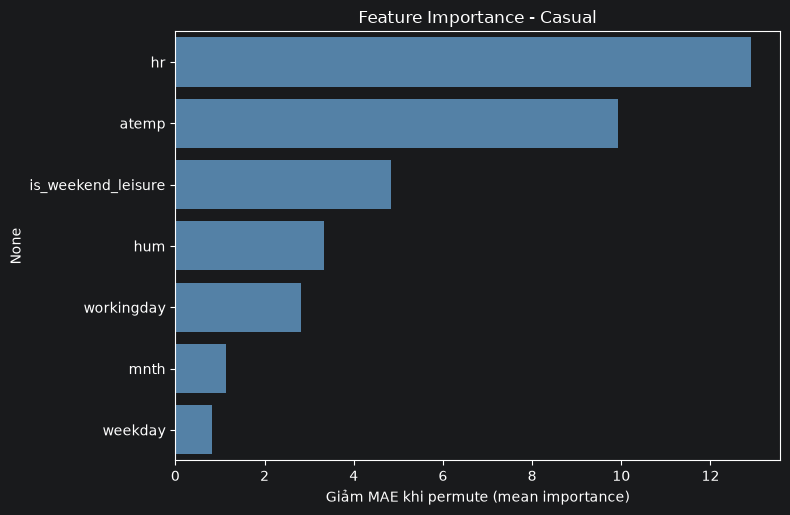

hr                    12.912888
atemp                  9.934425
is_weekend_leisure     4.839617
hum                    3.339076
workingday             2.810200
mnth                   1.130200
weekday                0.826805
dtype: float64

In [16]:
plot_feature_importance(best_casual, X_test_casual, y_test_casual, title="Feature Importance - Casual")

In [17]:
X_train_registered = pd.read_csv("../datas/X_train_registered.csv")
y_train_registered = pd.read_csv("../datas/y_train_registered.csv").iloc[:, 0]

X_test_registered = pd.read_csv("../datas/X_test_registered.csv")
y_test_registered = pd.read_csv("../datas/y_test_registered.csv").iloc[:, 0]

In [18]:
cat_cols = ["mnth","hr","weekday","workingday","is_weekend_leisure","is_rush_hour"]

In [19]:
X_train_registered[cat_cols] = X_train_registered[cat_cols].astype("category")
X_test_registered[cat_cols] = X_test_registered[cat_cols].astype("category")

In [20]:
best_registered, result_registered, raw_results_registered = get_result_evaluate(
    X_train_registered, y_train_registered, n_splits=N_SPLITS, gap=CV_GAP
)


  KẾT QUẢ TỔNG HỢP (sort theo MAE tăng dần)
                       Model  MAE (mean)  MAE (std)  RMSE (mean)  RMSE (std)  R² (mean)  R2 (std)
                    LightGBM   53.936935  21.137679    78.011636   27.132066   0.661493  0.148517
               Random Forest   53.998623  19.946301    78.586700   25.624267   0.657814  0.141280
                     XGBoost   54.538566  20.437287    79.340926   26.788413   0.649483  0.151223
               Decision Tree   56.117612  19.195875    81.444512   24.992313   0.630751  0.147726
Linear Regression (Baseline)   64.364294  15.726104    88.069990   21.999480   0.585641  0.088638

✅ Model tốt nhất : LightGBM
   MAE  = 53.9369 ± 21.1377
   RMSE = 78.0116
   R²   = 0.6615
   Params: {'lgb__colsample_bytree': 1.0, 'lgb__learning_rate': 0.05, 'lgb__max_depth': 9, 'lgb__n_estimators': 300, 'lgb__num_leaves': 20, 'lgb__subsample': 0.8}


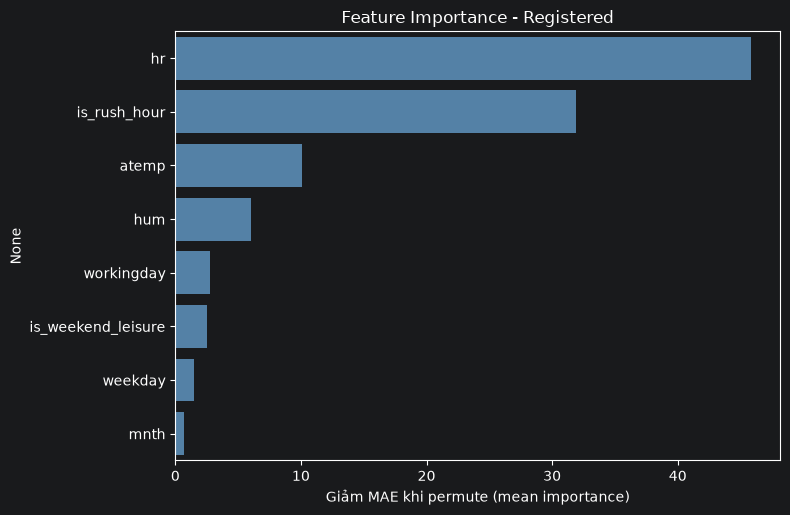

hr                    45.849030
is_rush_hour          31.923086
atemp                 10.053481
hum                    6.049928
workingday             2.780277
is_weekend_leisure     2.500500
weekday                1.503081
mnth                   0.705069
dtype: float64

In [21]:
plot_feature_importance(best_registered, X_test_registered, y_test_registered, title="Feature Importance - Registered")

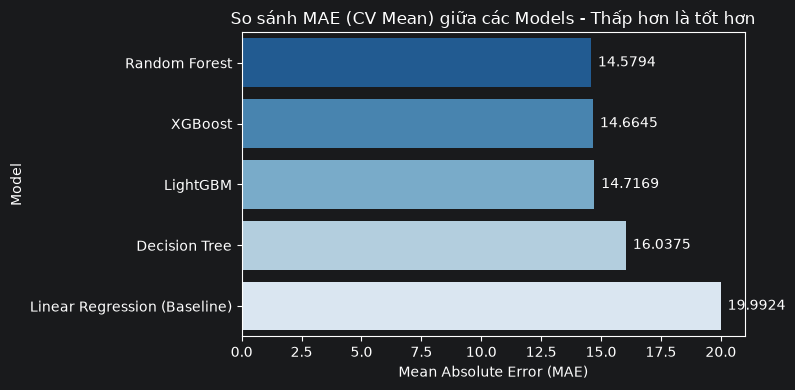

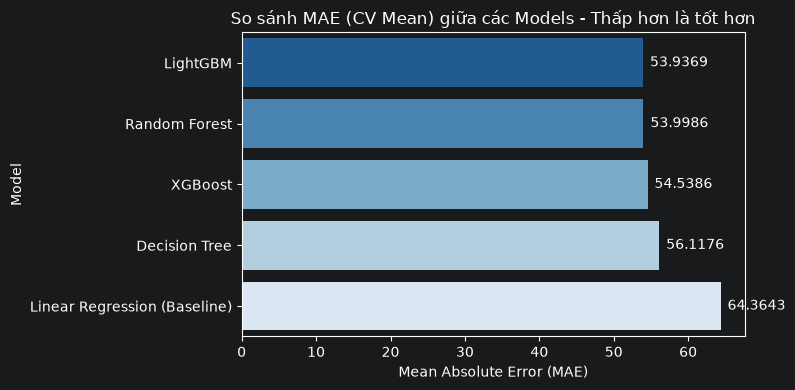

In [22]:
plot_result_evaluates(results=result_casual)
plot_result_evaluates(results=result_registered)

In [23]:
os.makedirs("models", exist_ok=True)
joblib.dump(best_casual, "models/best_casual_rf.joblib", compress=3)
joblib.dump(best_registered, "models/best_registered_rf.joblib", compress=3)

print("Đã lưu thành công các model vào thư mục 'models/'")

Đã lưu thành công các model vào thư mục 'models/'
